# E3D-2 · 3D 足端接触：平滑法向 + 摩擦锥（可微）

**目的**：把 2D 的接触梯度结论（E1 法向、F1 摩擦）迁移到 3D 平地足端接触，并按项目踩坑清单把 frame 钉死。

**设计优先级（本项目硬性教训）**：
1. **frame 全部写死**：此处一律 **WORLD 系**——足端位置/速度入、接触力出，地面法向 `n=+Z`。**绝不**把 body-frame 足速与 world-frame 法向混用（会悄悄翻转摩擦方向）。world↔body 只在 `floating_base_srbd.contact_to_body_wrench` 一处发生。
2. **可微近似，不硬投影**：法向用 softplus 罚；摩擦用 tanh 饱和锥，使 `‖f_t‖≤μf_n` **结构成立**且梯度处处有界（无 sign/硬 clamp）。
3. 摩擦**对抗**切向滑动速度（耗散）：`f_t·v_t ≤ 0` 恒成立。

模型（平地 z=0，法向 +Z）：`pen=eps·softplus(-gap/eps)`、`f_n=k_n·pen+k_d·gate·srelu(-vn)`（srelu 在 vn=0 处恰为 0，无静止伪力）、`v_t=v_foot−vn·n`、`f_t=−μf_n·tanh(|v_t|/v_eps)·v_t/|v_t|`。

In [1]:
import sys
from pathlib import Path
import torch
ROOT = Path.cwd().parent
for s in ('dynamics','models','scripts'): sys.path.insert(0, str(ROOT/s))
from contact_3d import ContactParams, foot_contact_force_world
DEV = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print('device', DEV)

# one foot: 3mm penetration, sliding +x @0.2 m/s, descending @0.1 m/s
pf = torch.tensor([[0.1,0.0,-0.003]], device=DEV, requires_grad=True)
vf = torch.tensor([[0.2,0.0,-0.1]], device=DEV, requires_grad=True)
o = foot_contact_force_world(pf, vf, ContactParams())
ft = o['f_t'][0]; print(f"f_n={o['f_n'].item():.2f}N  |f_t|={ft.norm().item():.2f}N  mu*f_n={o['mu_fn'].item():.2f}N")
print(f"cone ok: {ft.norm().item() <= o['mu_fn'].item()+1e-5} | dissipative f_t·v_t={(o['f_t'][0]*o['v_t'][0]).sum().item():+.3f} (<=0)")
o['f_world'].sum().backward(); print('differentiable & GPU:', torch.isfinite(pf.grad).all().item(), o['f_world'].device)

device cuda:0


f_n=62.83N  |f_t|=50.23N  mu*f_n=50.27N
cone ok: True | dissipative f_t·v_t=-10.047 (<=0)
differentiable & GPU: True cuda:0


## 验证 K1–K6（含 SRBD 落地积分）
调用 `scripts/e3d2_contact_checks.py`。

In [2]:
import numpy as np
import e3d2_contact_checks as chk
depths = np.linspace(-0.004, 0.012, 200); speeds = np.linspace(-0.3, 0.3, 200)
_ = chk.k1_normal(depths)
_ = chk.k2_friction(speeds)
_ = chk.k3_k4_cone_direction()
_ = chk.k6_drop_settle(DEV)

[K1 normal] smooth max|df_n/dd|=9975.3  hard max|df_n/dd|=10000.0 (hard has the step at d=0)
[K2 friction] smooth max|d|f_t|/dv|=544.0  hard max|d|f_t|/dv|=0.0 (hard ~inf at v=0)
[K3 cone] max ||f_t||/(mu f_n)=1.0000  violations=0.00%
[K4 direction] f_t·v_t max=-1.67e-02  non-dissipative=0.00%


[K6 drop-settle] rest COM z=0.2426 m  sum f_n(rest)=147.3 N  m g=147.3 N  balance err=0.0%  (device cuda:0)


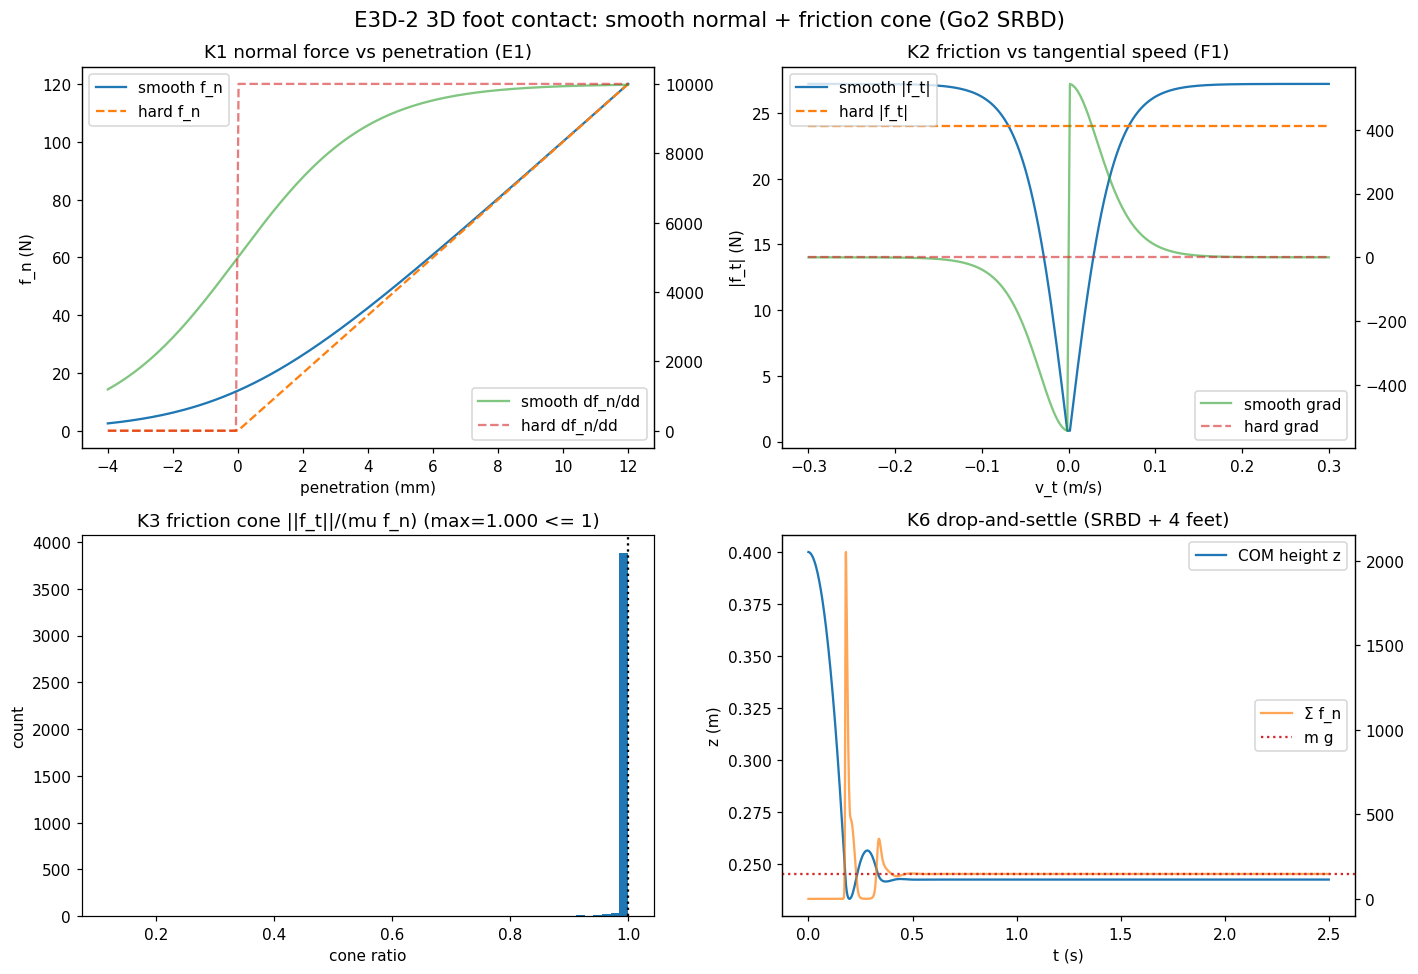

In [3]:
from IPython.display import Image
Image(str(ROOT / 'figures' / 'e3d2_contact_checks.png'))

## 结论（E3D-2）
- **K1 法向（E1 3D 版）**：平滑法向力梯度连续有界（~k_n）；硬接触在接触起始处梯度不连续（阶跃）。
- **K2 摩擦（F1 3D 版）**：平滑库仑给出**有界且有信息**的切向梯度（峰值~544）；硬库仑切向梯度恒 0（无信息）——与 2D F1 一致。
- **K3 摩擦锥**：`‖f_t‖/(μf_n) ≤ 1` 结构成立，违反率 0%。
- **K4 方向（frame 踩坑检查）**：`f_t·v_t ≤ 0` 恒成立（耗散），证明 world 足速与 world 法向 frame 一致、摩擦方向没反。
- **K6 落地积分**：Go2 SRBD + 4 足经 `contact_to_body_wrench` 落地，稳定 settle 到 COM z≈0.243 m，静止时 **Σf_n = m g（误差 0%）**——接触→SRBD 力矩换算与积分回路正确。
- 全程可微、可在 3080 GPU 跑。

下一步 E3D-3：3D SRBD 原地站立闭环最小可微训练（平滑接触 + 目标损失 + GDecay/短视野），对照 smooth/hard。